## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results DiffGoL Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (25,25)
model_name = 'DiffGoL'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

cols2omit = 1
num_rows = 1
threshold = 0.5

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoL Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

metrics2compute = ['Accuracy', 'Recall', 'Specificity','Precision', 'F1Score']

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.5845 ± 0.0023
val_loss: 0.5879 ± 0.0037


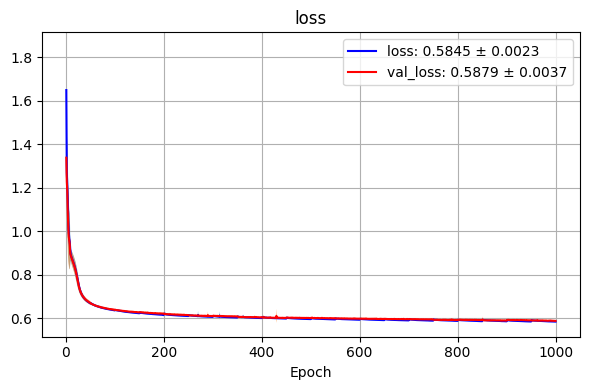

In [4]:
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8669 ± 0.0004
Accuracy_fin: 0.9194 ± 0.0011
Recall_init: 0.6489 ± 0.0024
Recall_fin: 0.6223 ± 0.0054
Specificity_init: 0.9239 ± 0.0004
Specificity_fin: 0.9933 ± 0.0003
Precision_init: 0.6900 ± 0.0009
Precision_fin: 0.9588 ± 0.0017
F1Score_init: 0.6688 ± 0.0013
F1Score_fin: 0.7548 ± 0.0040


--- Results Initial States (15 seeds) ---
Density (true): 20.71% ± 8.76%
Density (pred): 22.05% ± 9.05%
Error/seed:     1.34% ± 0.05%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.12% ± 0.03%
HUC% (0.4, 0.6): 4.34% ± 0.06%
HUC% (0.35, 0.65): 6.79% ± 0.07%
Fuzziness Index: 0.2547 ± 0.1321
MSE (prob):0.1003 ± 0.0563
MSE (bin):0.1331 ± 0.0766
MSE (all-zero): 0.2071 ± 0.0876
Wasserstein (EMD): 1.4887 ± 0.0032


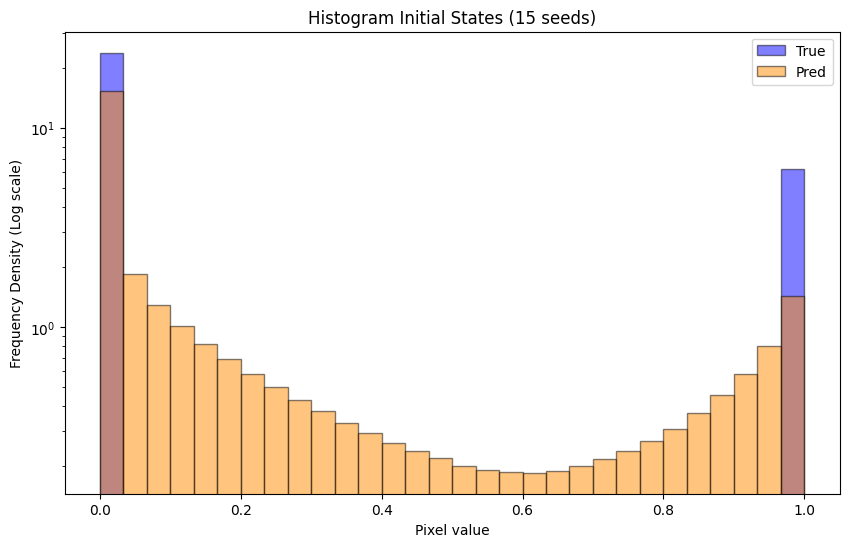

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 19.93% ± 8.62%
Density (pred): 12.43% ± 4.61%
Error/seed:     7.51% ± 0.08%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.26% ± 0.03%
HUC% (0.4, 0.6): 4.55% ± 0.06%
HUC% (0.35, 0.65): 6.85% ± 0.08%
Fuzziness Index: 0.1596 ± 0.0809
MSE (prob):0.0530 ± 0.0319
MSE (bin):0.0806 ± 0.0505
MSE (all-zero): 0.1993 ± 0.0862
Wasserstein (EMD): 1.7076 ± 0.0052


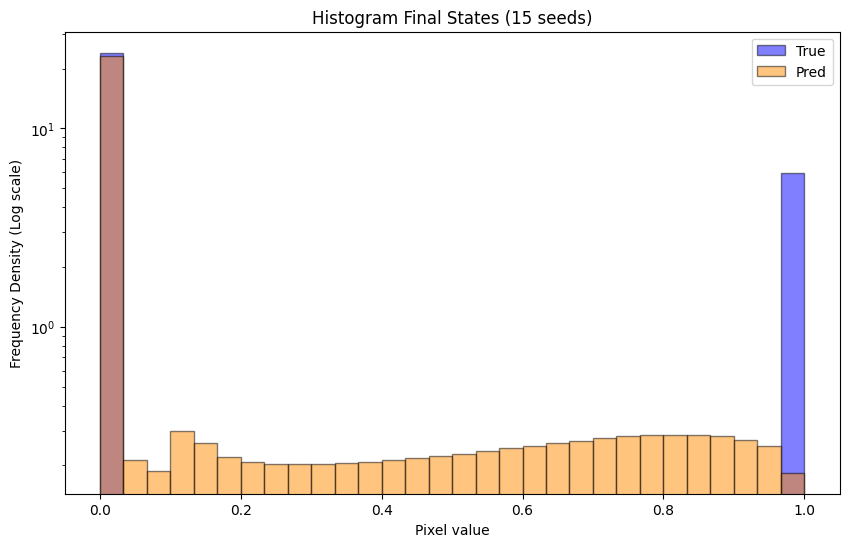

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

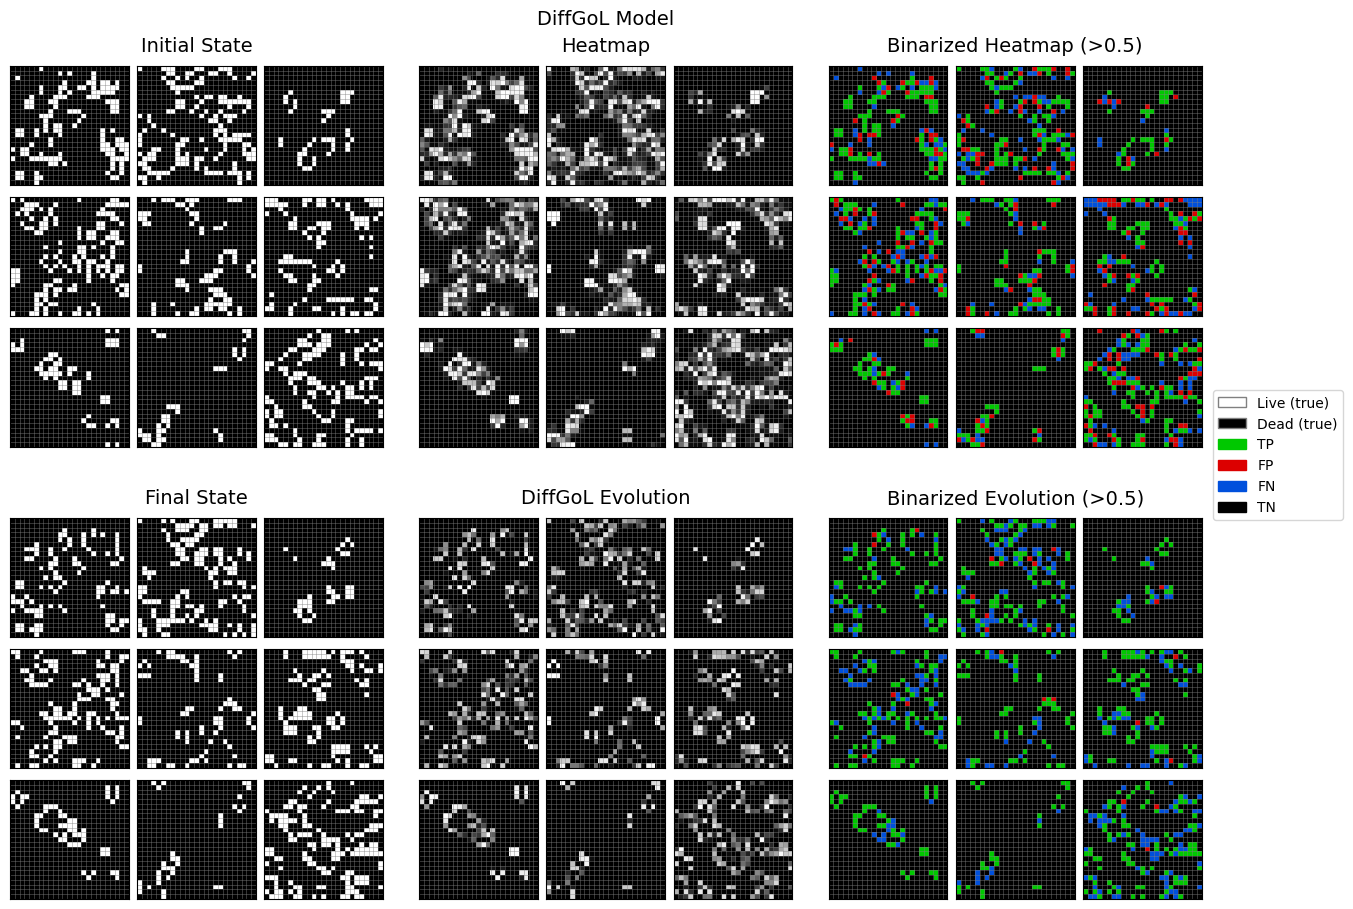

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False) 

Threshold: 0.2109 ± 0.0019


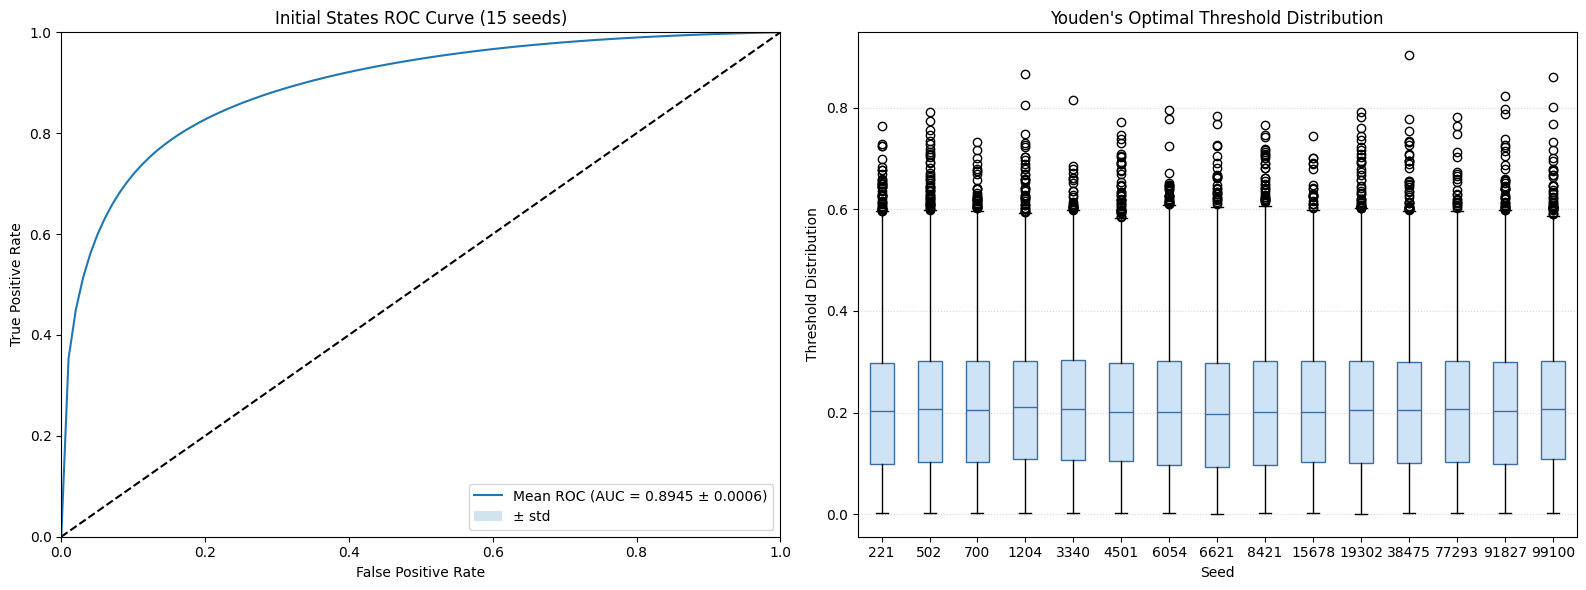

Threshold: 0.0805 ± 0.0015


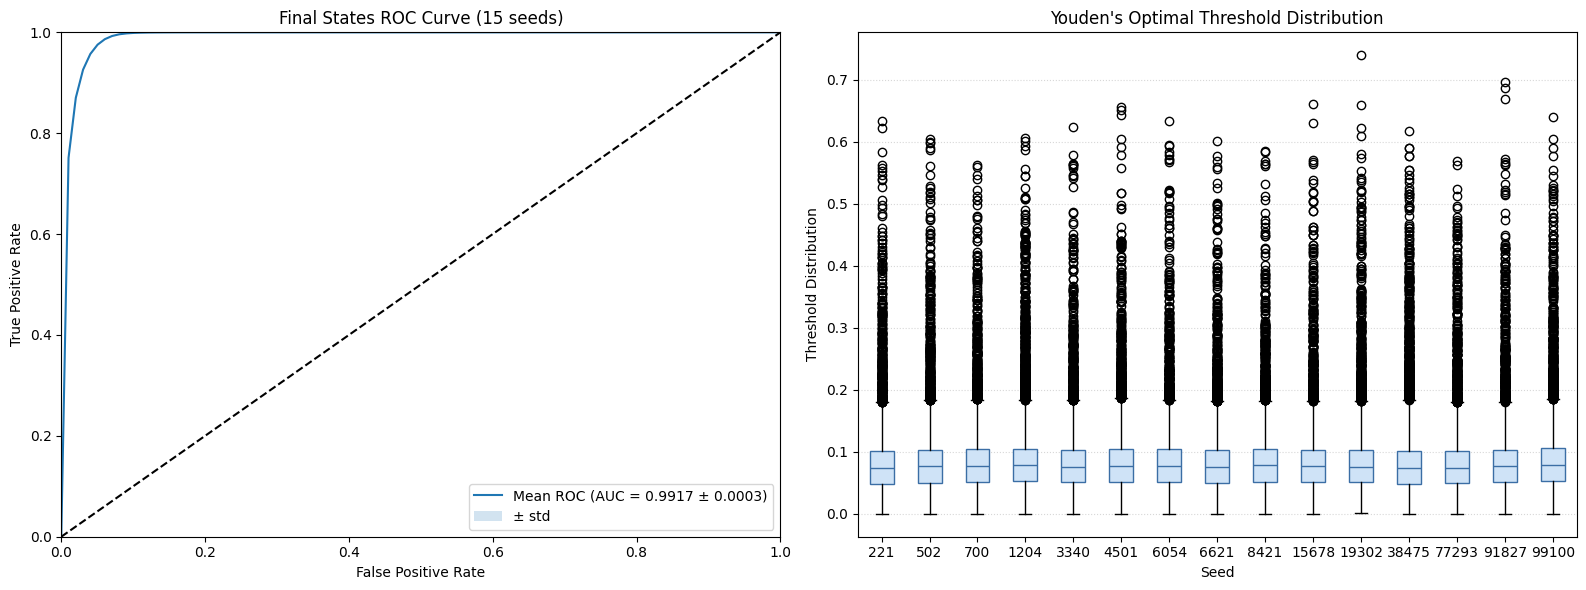

In [9]:
eval_tools.computeROC(predictions_paths, test_data, 'init', shape)
eval_tools.computeROC(predictions_paths, test_data, 'fin', shape)